In [1]:
import toml
import os
import sys
workspace_root = os.getcwd()
sys.path.insert(0, workspace_root + "/../../..")
from analysis import Analysis

In [2]:
# ANALYSIS SPECIFIC DIRECTORIES
ana_directory = "../../1muNp0pi_Nge1_uncontained"
data_file = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root'

[mc] varied-response method applied to 52 interaction dial(s).

Processing systematics for sample: mc
[G4_proton] reco_dpT_contained: 20 bins, fractional sigma 1.32%..3.64%, integrated 1.85%
[G4_proton] reco_dpT_exiting: 10 bins, fractional sigma 1.66%..2.90%, integrated 2.29%
[G4_piplus] reco_dpT_contained: 20 bins, fractional sigma 0.03%..0.79%, integrated 0.20%
[G4_piplus] reco_dpT_exiting: 10 bins, fractional sigma 0.21%..0.77%, integrated 0.40%
[G4_piminus] reco_dpT_contained: 20 bins, fractional sigma 0.02%..0.75%, integrated 0.09%
[G4_piminus] reco_dpT_exiting: 10 bins, fractional sigma 0.03%..0.22%, integrated 0.10%
--Systematic(var01, None)--
	Fractional uncertainty: 1.47%
--Systematic(var01_sigma, None)--
	Fractional uncertainty: 91.51%
--Systematic(var02, None)--
	Fractional uncertainty: 1.12%
--Systematic(var02_sigma, None)--
	Fractional uncertainty: 90.93%
--Systematic(var03, None)--
	Fractional uncertainty: 1.09%
--Systematic(var03_sigma, None)--
	Fractional uncertainty: 

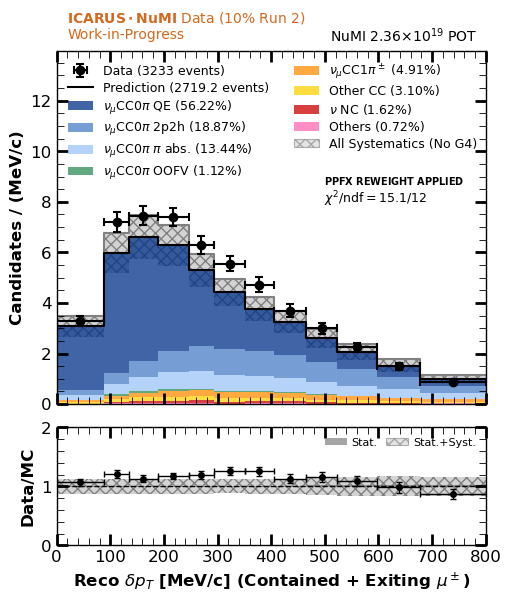

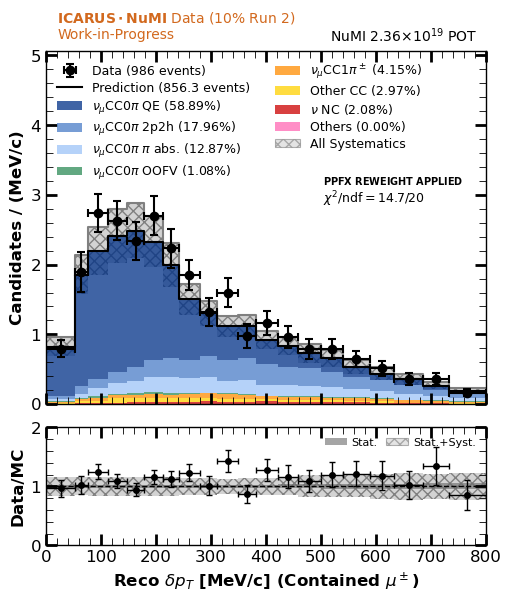

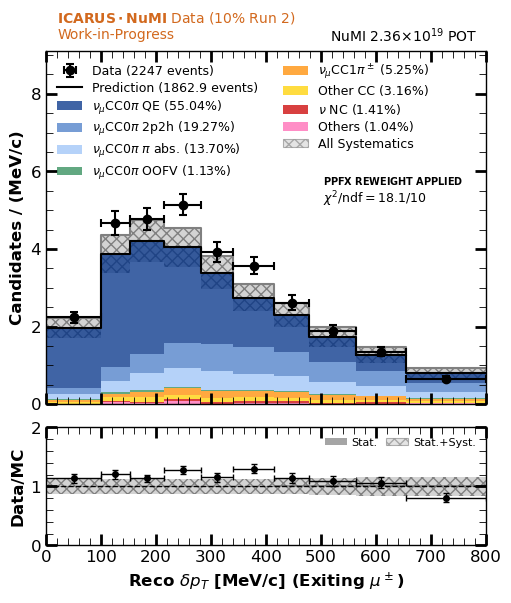

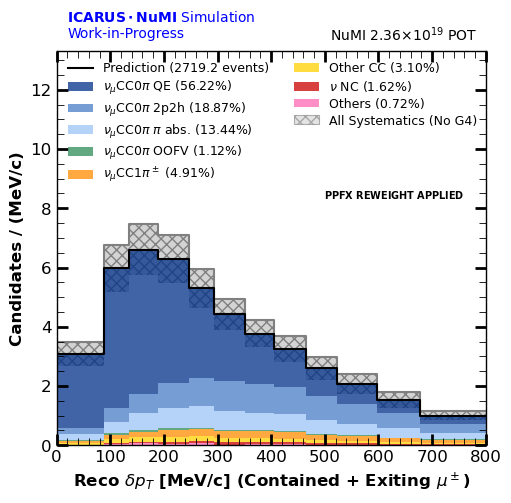

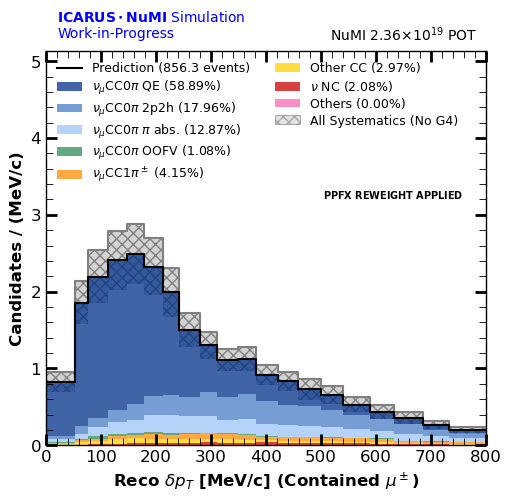

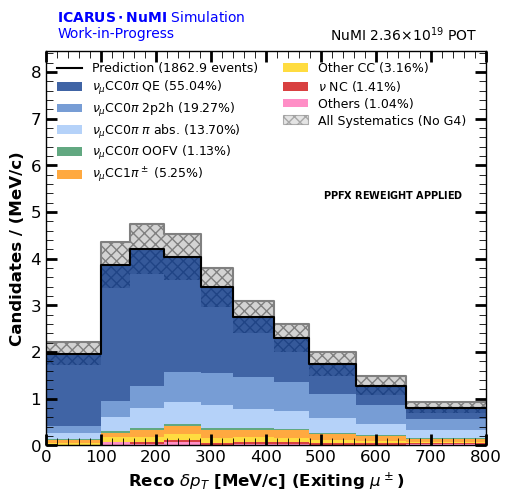

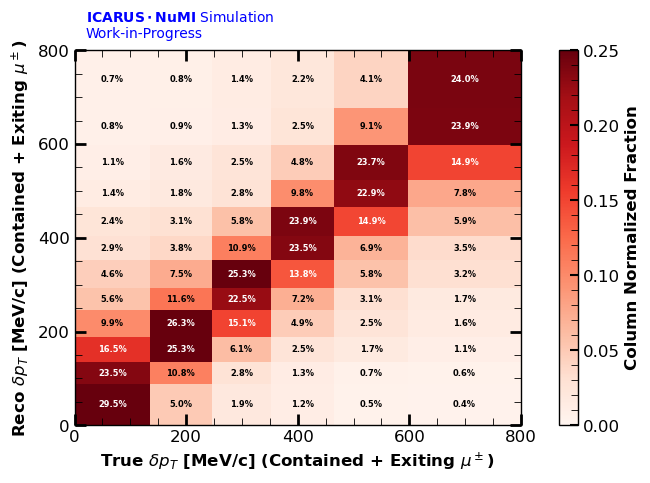

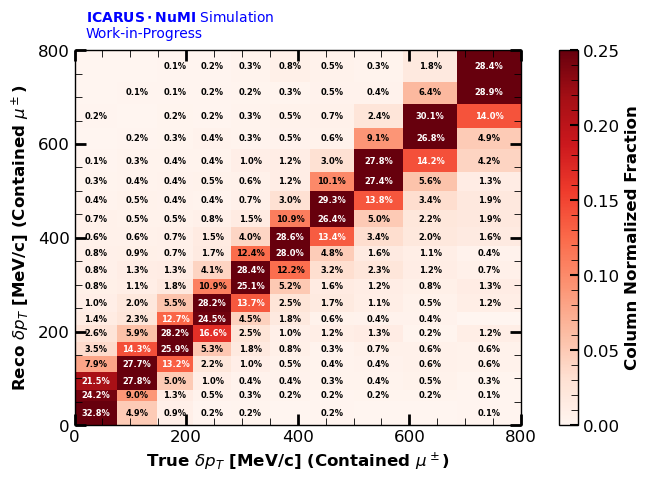

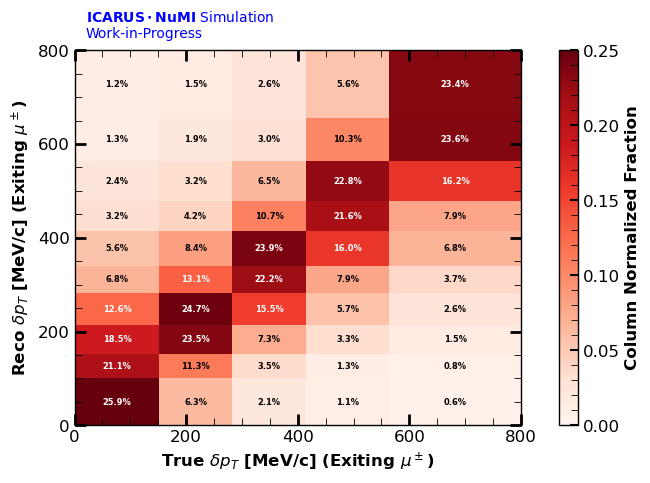

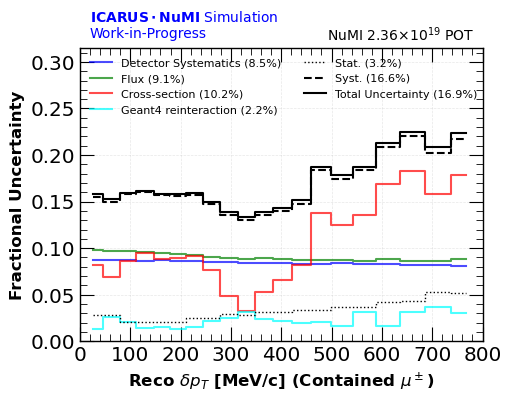

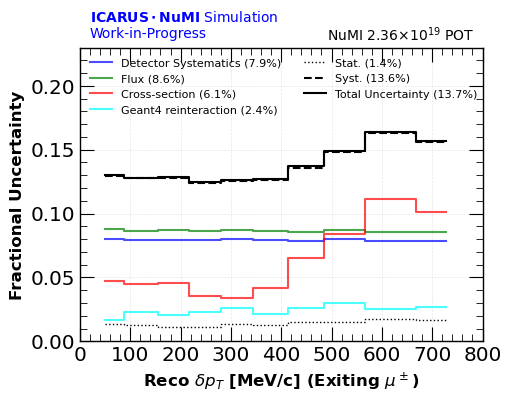

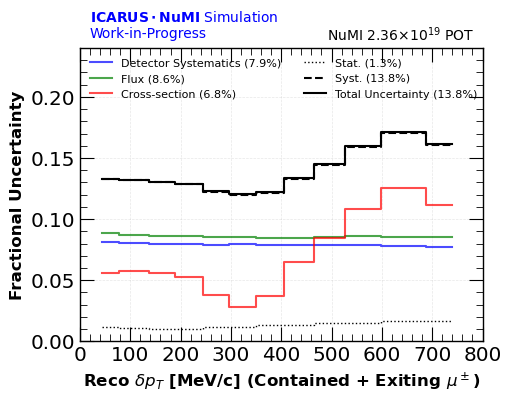

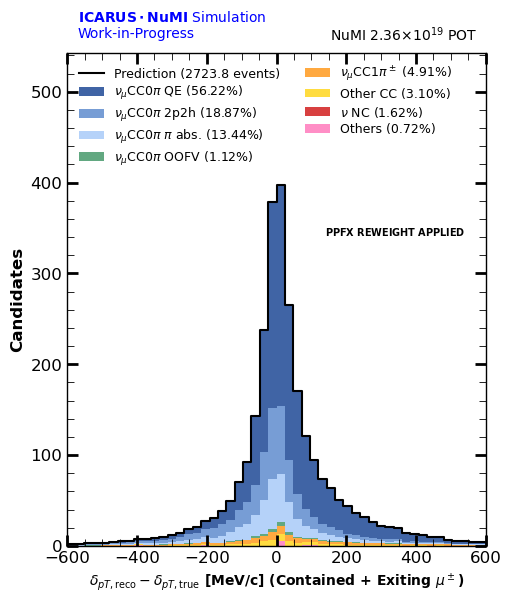

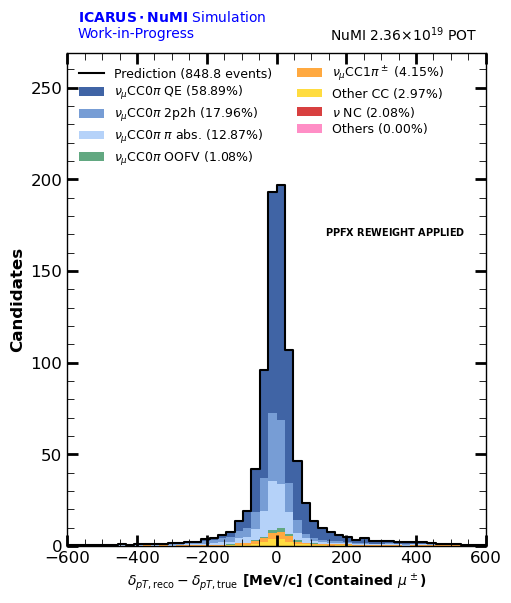

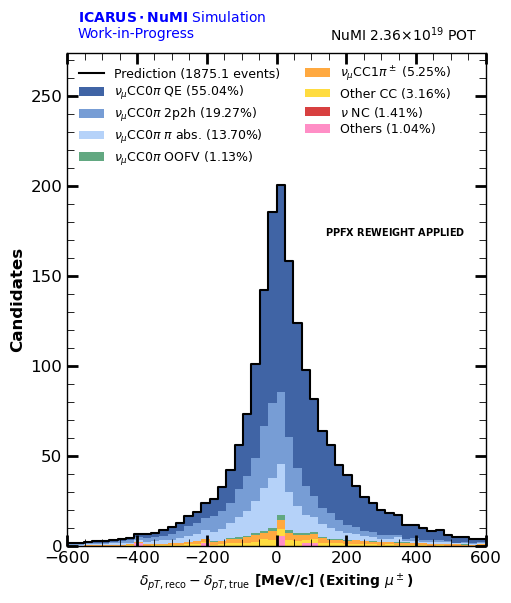

In [3]:
analysis = Analysis(ana_directory + '/dpT/dpT.toml', data_file)
analysis.run(close_figs=False)

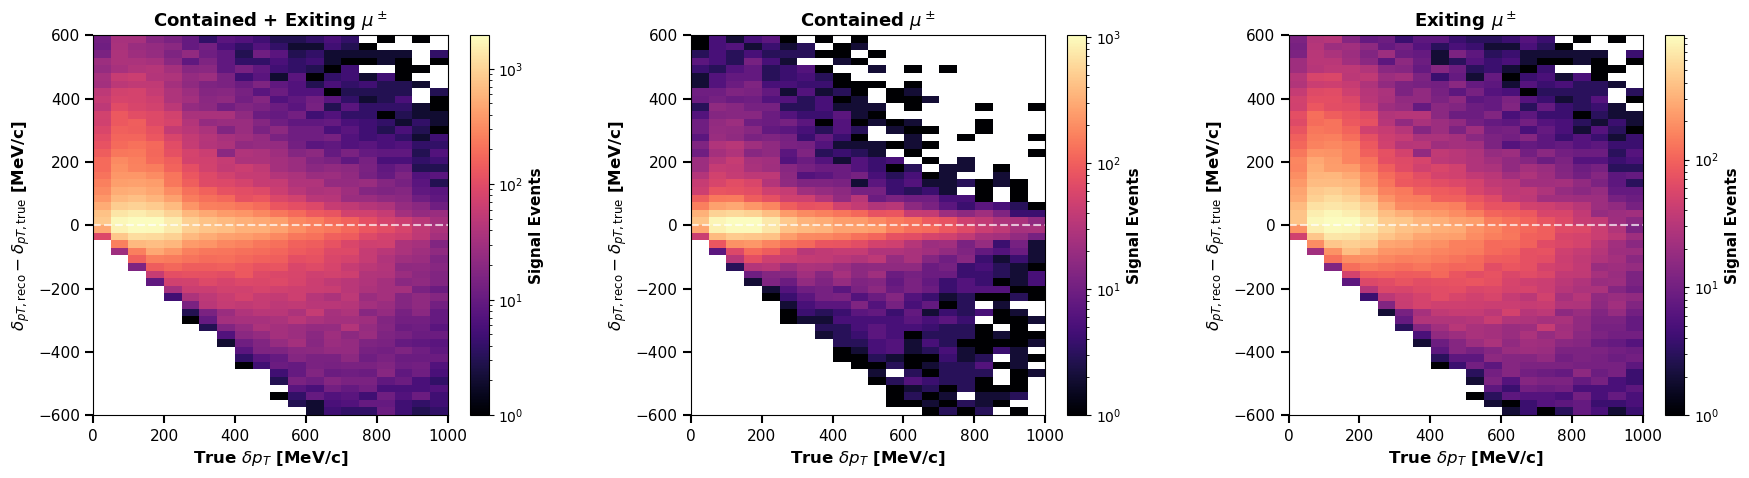

In [5]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# File and tree
fpath = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_gundam_withPCA.root'

with uproot.open(fpath) as f:
    tree = f['events/full/selected']
    reco_dpT       = tree['reco_dpT_lp'].array(library='np')
    true_dpT       = tree['true_dpT_lp_genie'].array(library='np')
    true_category  = tree['true_category'].array(library='np')
    muon_contained = tree['reco_leading_muon_containment'].array(library='np')

# Signal categories
signal_mask = np.isin(true_category, [0, 1, 3, 4])

# Valid kinematics mask
valid_mask = (
    np.isfinite(true_dpT) &
    np.isfinite(reco_dpT) &
    (reco_dpT < 5000) &
    (true_dpT < 5000)
)

# Compute absolute residual
abs_residual = reco_dpT - true_dpT

# Combined, contained, exiting masks
combined_mask  = signal_mask & valid_mask
contained_mask = signal_mask & valid_mask & (muon_contained == 1)
exiting_mask   = signal_mask & valid_mask & (muon_contained == 0)

# Binning
x_bins = np.linspace(0, 1000, 21)
y_bins = np.linspace(-600, 600, 51)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(left=0.07, right=0.98, top=0.88, bottom=0.12, wspace=0.35)

titles = [
    r'Contained + Exiting $\mu^\pm$',
    r'Contained $\mu^\pm$',
    r'Exiting $\mu^\pm$'
]
masks = [combined_mask, contained_mask, exiting_mask]

for ax, mask, title in zip(axes, masks, titles):
    h, xedges, yedges = np.histogram2d(
        true_dpT[mask],
        abs_residual[mask],
        bins=[x_bins, y_bins]
    )

    im = ax.imshow(
        h.T,
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        aspect='auto',
        origin='lower',
        norm=mcolors.LogNorm(vmin=1, vmax=h.max()),
        cmap='magma'
    )

    ax.axhline(y=0, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.set_xlabel(r'True $\delta p_T$ [MeV/c]', fontsize=12, fontweight='bold')
    ax.set_ylabel(r'$\delta_{pT,\mathrm{reco}} - \delta_{pT,\mathrm{true}}$ [MeV/c]',
                  fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=11, size=6, width=1.5)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Signal Events', fontsize=11, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)
plt.savefig('pdf/dpT_resolution_vs_true_dpT.pdf', bbox_inches='tight', dpi=150)
plt.show()

[mc] varied-response method applied to 52 interaction dial(s).

Processing systematics for sample: mc
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA1CCQE, None)-- [method=response]
	Fractional uncertainty: 0.20%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA1CCQE_sigma, None)--
	Fractional uncertainty: 86.82%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE, None)-- [method=response]
	Fractional uncertainty: 0.06%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE_sigma, None)--
	Fractional uncertainty: 87.72%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA3CCQE, None)-- [method=response]
	Fractional uncertainty: 0.09%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA3CCQE_sigma, None)--
	Fractional uncertainty: 87.95%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA4CCQE, None)-- [method=response]
	Fractional uncertainty: 0.02%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA4CCQE_sigma, None)--
	Fractional uncertainty: 90.58%
--Systematic(GENIEReWeight_SBN

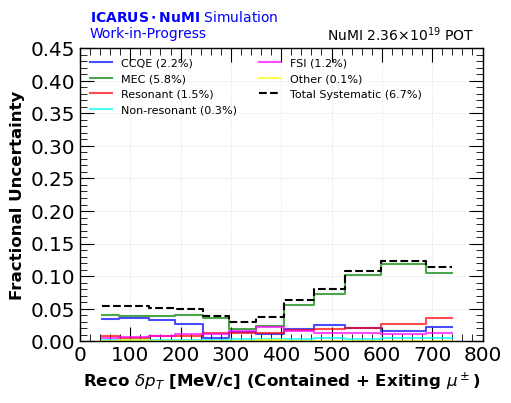

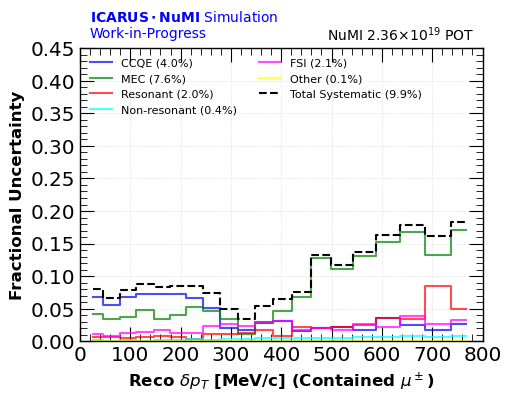

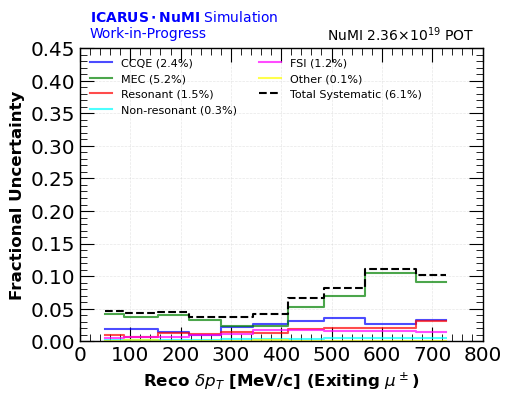

In [3]:
analysis = Analysis(ana_directory + '/dpT/dpT_xSecUncertainty.toml', data_file)
analysis.run(close_figs=False)


Processing systematics for sample: mc
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA1CCQE, None)--
	Fractional uncertainty: 7.25%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA1CCQE_sigma, None)--
	Fractional uncertainty: 87.95%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE, None)--
	Fractional uncertainty: 1.17%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE_sigma, None)--
	Fractional uncertainty: 89.70%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA3CCQE, None)--
	Fractional uncertainty: 1.96%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA3CCQE_sigma, None)--
	Fractional uncertainty: 93.34%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA4CCQE, None)--
	Fractional uncertainty: 0.69%
--Systematic(GENIEReWeight_SBN_v1_multisigma_ZExpA4CCQE_sigma, None)--
	Fractional uncertainty: 89.75%
--Systematic(GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape, None)--
	Fractional uncertainty: 0.17%
--Systematic(GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape_sigma

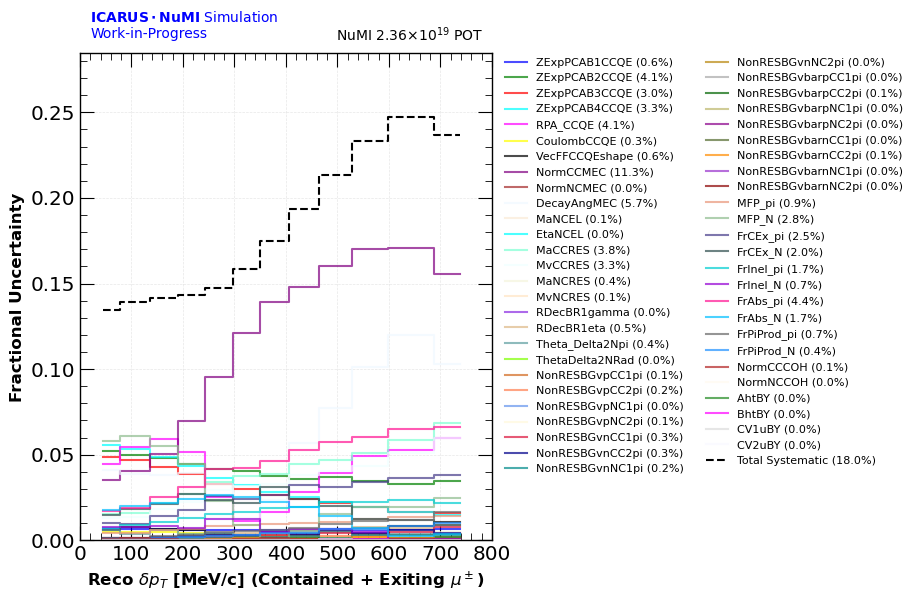

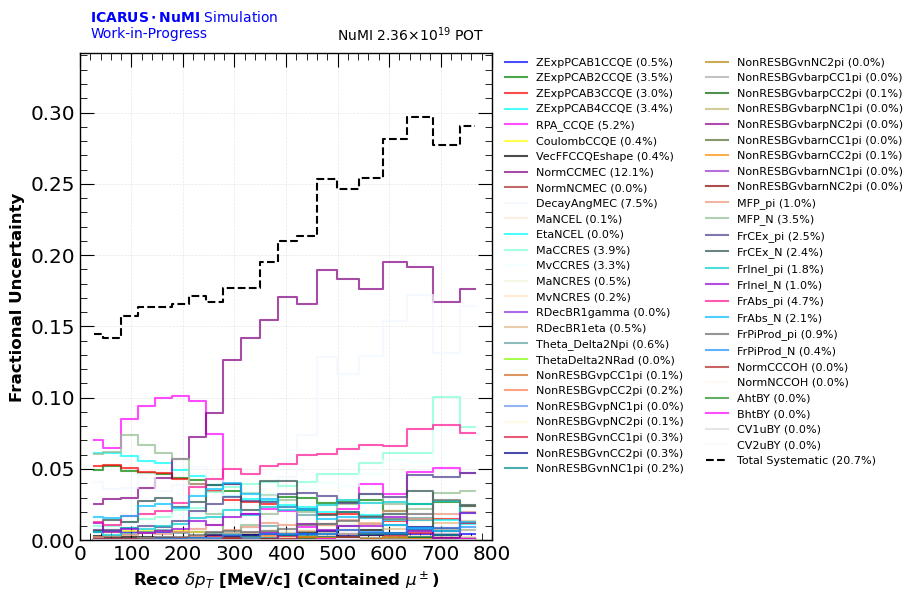

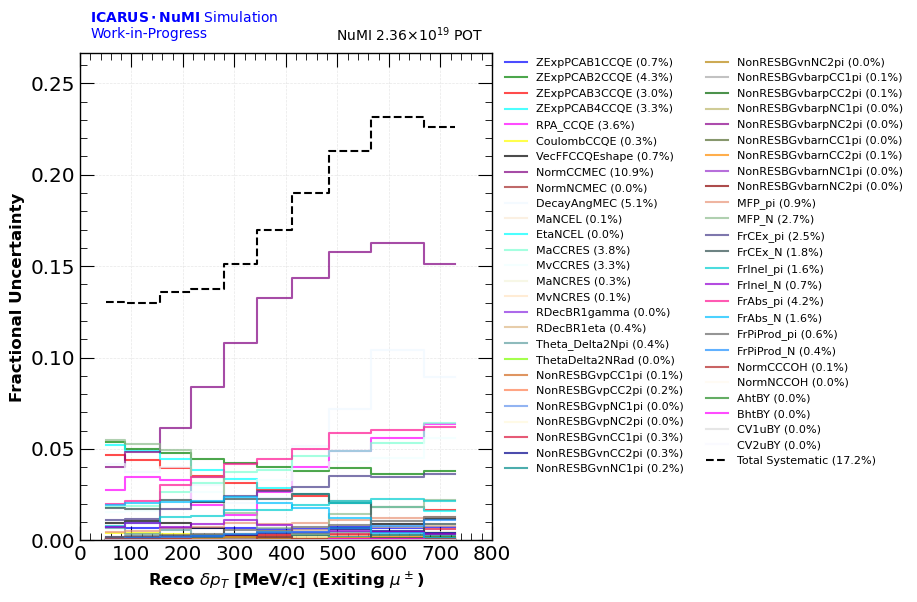

In [3]:
# Delta p_T cross-section uncertainties plot expanded
analysis = Analysis(ana_directory + '/dpT/dpT_xSecUncertainty_Exp.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Delta p_T flux uncertainties plot
analysis = Analysis(ana_directory + '/dpT/dpT_FluxUncertainty.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Delta p_T flux uncertainties plot expanded
analysis = Analysis(ana_directory + '/dpT/dpT_FluxUncertainty_Exp.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Delta p_T detector uncertainties plot
analysis = Analysis(ana_directory + '/dpT/dpT_DetectorUncertainty.toml', data_file)
analysis.run(close_figs=False)

true signal: 80175; fully contained: 23567 (29.4%)

  true dpT bin  N_full    bias    res |   N_nfc    bias    res
    0-50          1500    25.6   48.9 |    3661   113.5  163.5
   50-100         3360    10.9   46.3 |    7279    82.3  156.4
  100-150         3842     9.0   44.4 |    8268    59.3  154.8
  150-200         3617     3.6   42.6 |    7664    44.6  147.7
  200-250         2722     1.8   42.7 |    5653    28.4  138.6
  250-300         1566     1.6   46.9 |    3548    18.5  140.9
  300-400         2309    -1.1   46.5 |    5504     4.0  152.0
  400-500         1739    -5.8   50.9 |    4695    -6.8  156.7
  500-650         1650   -10.8   66.7 |    4794   -28.1  183.9
  650-800          782   -17.7   91.0 |    2914   -57.2  222.3


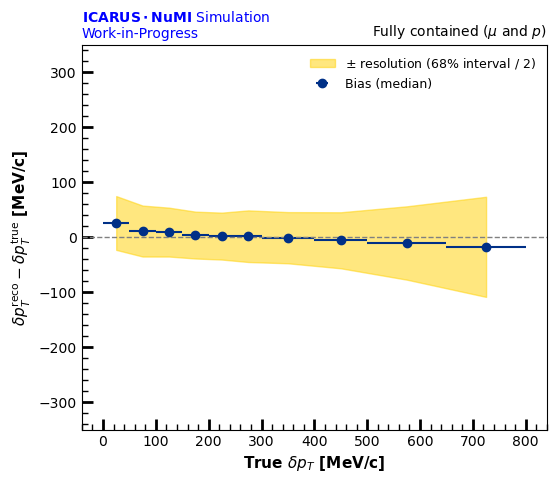

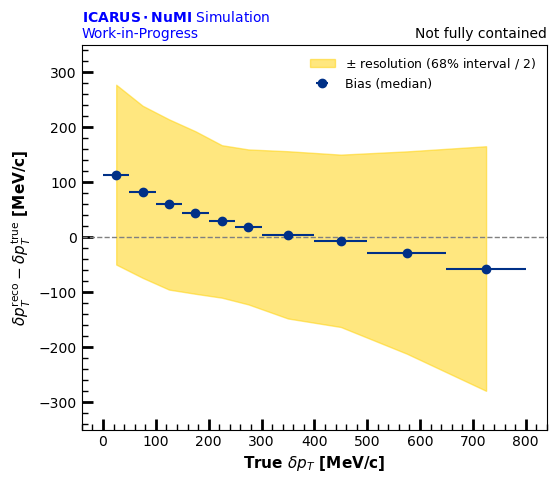

In [1]:
# dpT resolution vs true dpT, split by event containment -- reviewer
# question (London, Fig 16):
# "reco_delta_pT - true_delta_pT in bins of true_delta_pT may be the best way
# to investigate the resolution for this variable. It would also be a good
# investigation of the above points about MCS resolutions to look at the
# delta_pT resolutions for fully contained and non-fully-contained events
# separately."
#
# Fully contained = leading muon AND leading proton contained (29.5% of the
# selected true-signal sample). Bias = median of reco - true per true-dpT bin;
# resolution = half the central 68% interval.

import os
import uproot
import numpy as np
import matplotlib.pyplot as plt

NAVY, GOLD, RED = "#003087", "#FFD100", "#CC0000"
SYST_FILE = (
    "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
    "My Drive/\U0001F3DB PhD Repository/\U0001F680 Research/\U0001F916 Experiments&Projects/"
    "ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root"
)

t = uproot.open(SYST_FILE)["events/full/selected"]
a = t.arrays(["true_category", "reco_leading_muon_containment",
              "reco_leading_proton_containment", "reco_dpT_lp",
              "true_dpT_lp_genie"], library="np")
sig = np.isin(a["true_category"], [0, 1, 3, 4]) & (a["true_dpT_lp_genie"] >= 0)
full = (a["reco_leading_muon_containment"] == 1) & (a["reco_leading_proton_containment"] == 1)
res = a["reco_dpT_lp"] - a["true_dpT_lp_genie"]
tru = a["true_dpT_lp_genie"]
print(f"true signal: {sig.sum()}; fully contained: {(sig & full).sum()} "
      f"({100 * (sig & full).sum() / sig.sum():.1f}%)")

edges = np.array([0., 50., 100., 150., 200., 250., 300., 400., 500., 650., 800.])
centers = 0.5 * (edges[:-1] + edges[1:])
half = 0.5 * np.diff(edges)

def profile(mask):
    bias, width = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        s = mask & (tru >= lo) & (tru < hi)
        q16, q50, q84 = np.percentile(res[s], [15.865, 50, 84.135])
        bias.append(q50)
        width.append(0.5 * (q84 - q16))
    return np.array(bias), np.array(width)

def style(ax, xl, yl, right):
    ax.set_xlabel(xl, fontsize=11, fontweight="bold", fontfamily="sans-serif")
    ax.set_ylabel(yl, fontsize=11, fontweight="bold", fontfamily="sans-serif")
    ax.tick_params(axis="both", which="major", labelsize=10, size=8, width=2, direction="in")
    ax.minorticks_on()
    ax.tick_params(axis="both", which="minor", size=4, width=1, direction="in")
    for l in ax.get_xticklabels() + ax.get_yticklabels():
        l.set_fontfamily("sans-serif")
    ax.text(ax.get_xlim()[0], ax.get_ylim()[1] * 1.02,
            r"$\bf{ICARUS \cdot NuMI}$ Simulation" + "\nWork-in-Progress",
            fontsize=10, color="blue", va="bottom", fontfamily="sans-serif")
    ax.text(ax.get_xlim()[1], ax.get_ylim()[1] * 1.02, right,
            fontsize=10, color="black", va="bottom", ha="right", fontfamily="sans-serif")

OUT_DIR = os.getcwd()
os.makedirs(os.path.join(OUT_DIR, "pdf"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "jpeg"), exist_ok=True)

print(f"\n{'true dpT bin':>14} {'N_full':>7} {'bias':>7} {'res':>6} | {'N_nfc':>7} {'bias':>7} {'res':>6}")
bf, wf = profile(sig & full)
bn, wn = profile(sig & ~full)
for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
    nf = ((sig & full) & (tru >= lo) & (tru < hi)).sum()
    nn = ((sig & ~full) & (tru >= lo) & (tru < hi)).sum()
    print(f"{lo:>5.0f}-{hi:<8.0f} {nf:>7d} {bf[i]:>7.1f} {wf[i]:>6.1f} | "
          f"{nn:>7d} {bn[i]:>7.1f} {wn[i]:>6.1f}")

for mask, tag, right in [(sig & full, "fully_contained", r"Fully contained ($\mu$ and $p$)"),
                         (sig & ~full, "not_fully_contained", r"Not fully contained")]:
    bias, width = profile(mask)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.fill_between(centers, bias - width, bias + width, color=GOLD, alpha=0.5,
                    label=r"$\pm$ resolution (68% interval / 2)")
    ax.errorbar(centers, bias, xerr=half, fmt="o", color=NAVY, label="Bias (median)")
    ax.axhline(0.0, color="gray", ls="--", lw=1)
    ax.set_ylim(-350, 350)
    ax.legend(fontsize=9, loc="upper right", framealpha=0.0, edgecolor="none")
    style(ax, r"True $\delta p_T$ [MeV/c]",
          r"$\delta p_T^{\rm reco} - \delta p_T^{\rm true}$ [MeV/c]", right)
    fig.savefig(os.path.join(OUT_DIR, f"pdf/dpT_bias_resolution_vs_true_{tag}.pdf"),
                bbox_inches="tight", dpi=300)
    fig.savefig(os.path.join(OUT_DIR, f"jpeg/dpT_bias_resolution_vs_true_{tag}.jpeg"),
                bbox_inches="tight", dpi=300)
    plt.show()


## Systematics split: signal-only and background-only

Runs the two new companion configs (`dpT_systematics_signal.toml`, `dpT_systematics_background.toml`) that restrict the sample to `true_category` in the signal set ({0,1,3,4}) or its complement, respectively, via `presel`. Each produces its own `systematics_dpT_{signal,background}[_contained|_exiting]` figures (fractional Flux/Xsec/Detsys/Stat breakdown), independent of the combined systematics_dpT figures already produced above.



Processing systematics for sample: mc
--Systematic(var01, None)--
	Fractional uncertainty: 1.27%
--Systematic(var01_sigma, None)--
	Fractional uncertainty: 88.69%
--Systematic(var02, None)--
	Fractional uncertainty: 0.89%
--Systematic(var02_sigma, None)--
	Fractional uncertainty: 85.61%
--Systematic(var03, None)--
	Fractional uncertainty: 0.84%
--Systematic(var03_sigma, None)--
	Fractional uncertainty: 88.12%
--Systematic(var04, None)--
	Fractional uncertainty: 0.40%
--Systematic(var04_sigma, None)--
	Fractional uncertainty: 87.66%
--Systematic(var05, None)--
	Fractional uncertainty: 1.21%
--Systematic(var05_sigma, None)--
	Fractional uncertainty: 86.69%
--Systematic(var06, None)--
	Fractional uncertainty: 0.73%
--Systematic(var06_sigma, None)--
	Fractional uncertainty: 89.16%
--Systematic(var07, None)--
	Fractional uncertainty: 0.43%
--Systematic(var07_sigma, None)--
	Fractional uncertainty: 87.05%
--Systematic(var08, None)--
	Fractional uncertainty: 1.02%
--Systematic(var08_sigma, N

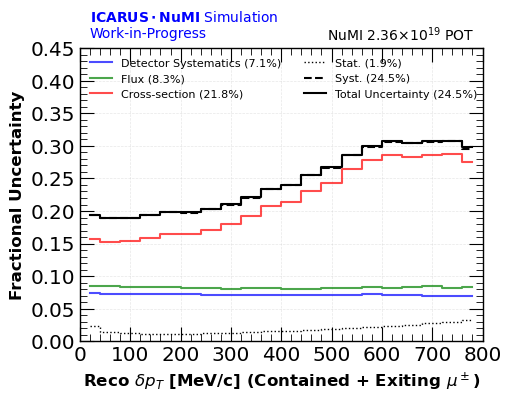

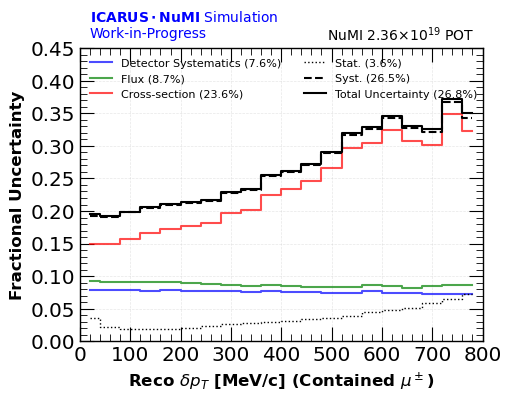

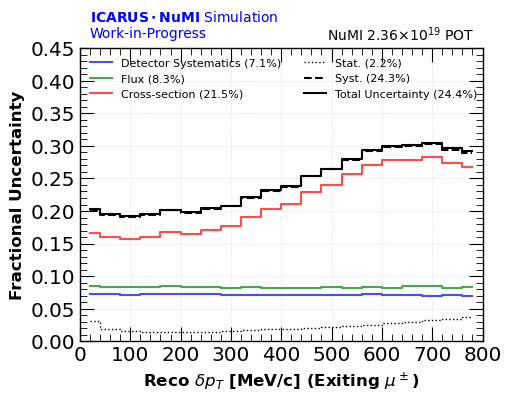

In [4]:
# Delta p_T systematics, SIGNAL ONLY (true_category in {0,1,3,4})
analysis = Analysis(ana_directory + '/dpT/dpT_systematics_signal.toml', data_file)
analysis.run(close_figs=False)



Processing systematics for sample: mc
--Systematic(var01, None)--
	Fractional uncertainty: 1.09%
--Systematic(var01_sigma, None)--
	Fractional uncertainty: 83.64%
--Systematic(var02, None)--
	Fractional uncertainty: 0.67%
--Systematic(var02_sigma, None)--
	Fractional uncertainty: 86.65%
--Systematic(var03, None)--
	Fractional uncertainty: 0.73%
--Systematic(var03_sigma, None)--
	Fractional uncertainty: 84.26%
--Systematic(var04, None)--
	Fractional uncertainty: 0.34%
--Systematic(var04_sigma, None)--
	Fractional uncertainty: 86.56%
--Systematic(var05, None)--
	Fractional uncertainty: 0.98%
--Systematic(var05_sigma, None)--
	Fractional uncertainty: 88.07%
--Systematic(var06, None)--
	Fractional uncertainty: 0.48%
--Systematic(var06_sigma, None)--
	Fractional uncertainty: 86.15%
--Systematic(var07, None)--
	Fractional uncertainty: 0.33%
--Systematic(var07_sigma, None)--
	Fractional uncertainty: 87.23%
--Systematic(var08, None)--
	Fractional uncertainty: 1.11%
--Systematic(var08_sigma, N

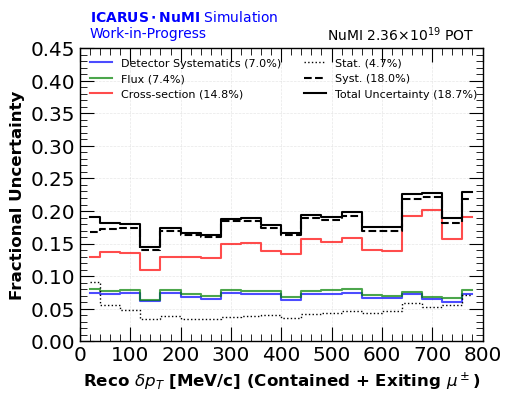

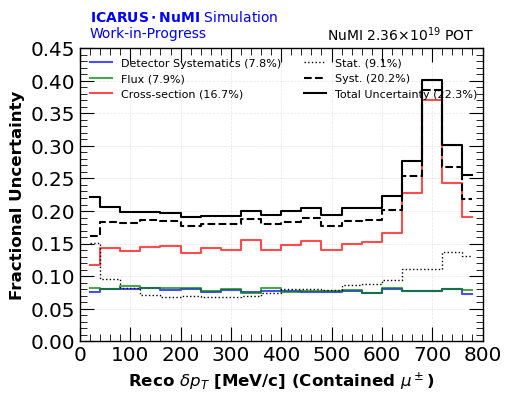

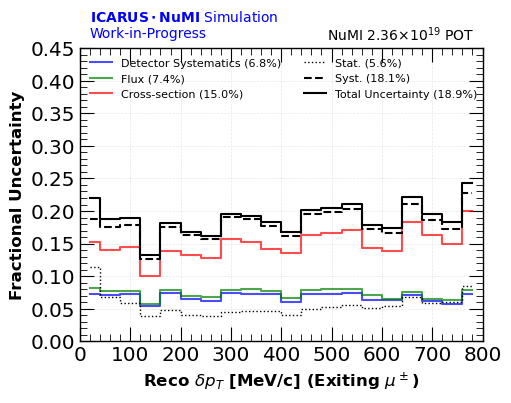

In [5]:
# Delta p_T systematics, BACKGROUND ONLY (true_category in {2,5,6,7,8,9,10} + rock/cosmic)
analysis = Analysis(ana_directory + '/dpT/dpT_systematics_background.toml', data_file)
analysis.run(close_figs=False)
